# Computer Exercise 14.1 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 응용 사례연구(Applied Case Studies) 확장
> **단원**: §14.1 Case Studies — *Ridge Regularization & k-Fold Cross-Validation*
> **풀이 일자**: Day 57
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

## 1. 문제 (원문)

> **3.** Fit a high-degree polynomial (or many correlated features) to noisy data using **ridge
> (Tikhonov) regularization** with penalty $\lambda\|\mathbf c\|_2^2$. Trace the **regularization
> path** of the coefficients as $\lambda$ varies, and select $\lambda$ by **$k$-fold cross-validation**.
> Compare the CV-chosen ridge fit against the unregularized least-squares fit.

### 한국어 풀이용 정리
잡음 데이터에 고차 다항 특징을 쓰면(설계행렬이 악조건) 일반 최소제곱은 계수가 폭발해 과대적합한다.
**릿지(티호노프) 정규화** $\lambda\|\mathbf c\|_2^2$ 를 더해 계수를 억제하고, $\lambda$ 를 바꿔가며
**정규화 경로**(계수의 궤적)를 그린다. 최적 $\lambda$ 는 **$k$-겹 교차검증**으로 고르고, 정규화 없는
최소제곱과 비교해 정규화가 악조건·과대적합을 어떻게 완화하는지 보인다.

## 2. 수학적 배경

### 2.1 릿지(티호노프) 정규화
$$
\min_{\mathbf c}\;\|V\mathbf c-\mathbf y\|_2^2+\lambda\|\mathbf c\|_2^2
\;\Longrightarrow\;
\boxed{\;\mathbf c(\lambda)=(V^\top V+\lambda I)^{-1}V^\top\mathbf y\;}
$$

$\lambda>0$ 이 $V^\top V$ 의 고유값을 $+\lambda$ 만큼 밀어 **조건수를 낮추고**, 해를 안정화한다
($\lambda\to0$ 이면 OLS, $\lambda\to\infty$ 이면 $\mathbf c\to 0$).

### 2.2 정규화 경로 & 편향-분산
$\lambda$↑ → 계수 수축(분산↓, 편향↑). 각 계수 $c_j(\lambda)$ 를 $\log\lambda$ 에 대해 그린 것이 **정규화 경로**.

### 2.3 $k$-겹 교차검증
데이터를 $k$ 조각으로 나눠, 매번 한 조각을 검증·나머지로 학습하여 평균 검증오차

$$
\mathrm{CV}(\lambda)=\frac1k\sum_{f=1}^{k}\mathrm{RMSE}_f(\lambda)
$$

를 최소화하는 $\lambda^\star$ 를 고른다. 절편/특징은 표준화 후 벌점을 준다.

## 3. 풀이 흐름

1. **참 함수**에서 잡음 데이터 생성, 고차 다항 설계행렬 $V$ 구성.
2. 열 **표준화**(평균0·분산1) — 릿지 벌점의 공정성 확보.
3. `ridge(V,y,λ)` = $(V^\top V+\lambda I)^{-1}V^\top y$ 구현.
4. $\lambda$ 격자(로그) 에 대해 **정규화 경로** 계수 저장.
5. **$k$-겹 CV**로 각 $\lambda$ 의 평균 검증 RMSE 계산 → $\lambda^\star$.
6. **표**: 대표 $\lambda$ 의 CV RMSE, 계수노름 $\|\mathbf c\|$, 조건수.
7. **시각화**: (a) 정규화 경로, (b) CV곡선, (c) OLS vs 릿지 적합.
8. **해석**: 계수 수축, 조건수 개선, 최적 $\lambda$ 의 일반화 이득.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(5712)

def f_true(x):
    return np.cos(3*x) * np.exp(-0.3*x**2)

n = 40
x = np.sort(rng.uniform(-2, 2, n))
sigma = 0.12
y = f_true(x) + rng.normal(0, sigma, n)

# --- 고차 다항 설계행렬 + 열 표준화 ---
deg = 12
Vraw = np.vander(x, deg+1, increasing=True)   # [1, x, x^2, ...]
mu = Vraw.mean(0); sd = Vraw.std(0); sd[0] = 1.0   # 절편 열은 그대로
V = (Vraw - mu)/sd
V[:,0] = 1.0
print(f"n={n}, degree={deg}, design cond(OLS) = {np.linalg.cond(V.T@V):.3e}")


n=40, degree=12, design cond(OLS) = 1.489e+08


In [2]:
def ridge_fit(Vtr, ytr, lam):
    p = Vtr.shape[1]
    R = np.eye(p); R[0,0] = 0.0          # 절편은 벌점 제외
    return np.linalg.solve(Vtr.T@Vtr + lam*R, Vtr.T@ytr)

def rmse(a,b): return np.sqrt(np.mean((a-b)**2))

lams = np.logspace(-6, 3, 60)

# --- 정규화 경로 (전체 데이터) ---
path = np.array([ridge_fit(V, y, l) for l in lams])   # (n_lam, p)

# --- k-겹 교차검증 ---
k = 5
folds = np.array_split(rng.permutation(n), k)
cv = []
for l in lams:
    errs = []
    for i in range(k):
        te = folds[i]; trn = np.concatenate([folds[j] for j in range(k) if j!=i])
        c_ = ridge_fit(V[trn], y[trn], l)
        errs.append(rmse(V[te]@c_, y[te]))
    cv.append(np.mean(errs))
cv = np.array(cv)
best = int(np.argmin(cv)); lam_star = lams[best]
print(f"최적 lambda* = {lam_star:.4e},  CV RMSE = {cv[best]:.4f}")


최적 lambda* = 1.0000e-06,  CV RMSE = 0.1356


In [3]:
c_ols   = ridge_fit(V, y, 0.0)
c_ridge = ridge_fit(V, y, lam_star)
tab = pd.DataFrame({
    "lambda": [0.0, lam_star, 1e2],
    "CV_RMSE": [cv[0], cv[best], cv[-1] if lams[-1]>=1e2 else np.nan],
    "||c||_2": [np.linalg.norm(c_ols), np.linalg.norm(c_ridge),
                np.linalg.norm(ridge_fit(V,y,1e2))],
})
pd.set_option("display.float_format", lambda v: f"{v:.4e}")
print(tab.to_string(index=False))
print(f"\n||c||: OLS={np.linalg.norm(c_ols):.3e}  ->  ridge(lambda*)={np.linalg.norm(c_ridge):.3e}  (수축)")


    lambda    CV_RMSE    ||c||_2
0.0000e+00 1.3563e-01 1.0504e+02
1.0000e-06 1.3563e-01 8.3770e+01
1.0000e+02 5.2930e-01 6.0867e-02

||c||: OLS=1.050e+02  ->  ridge(lambda*)=8.377e+01  (수축)


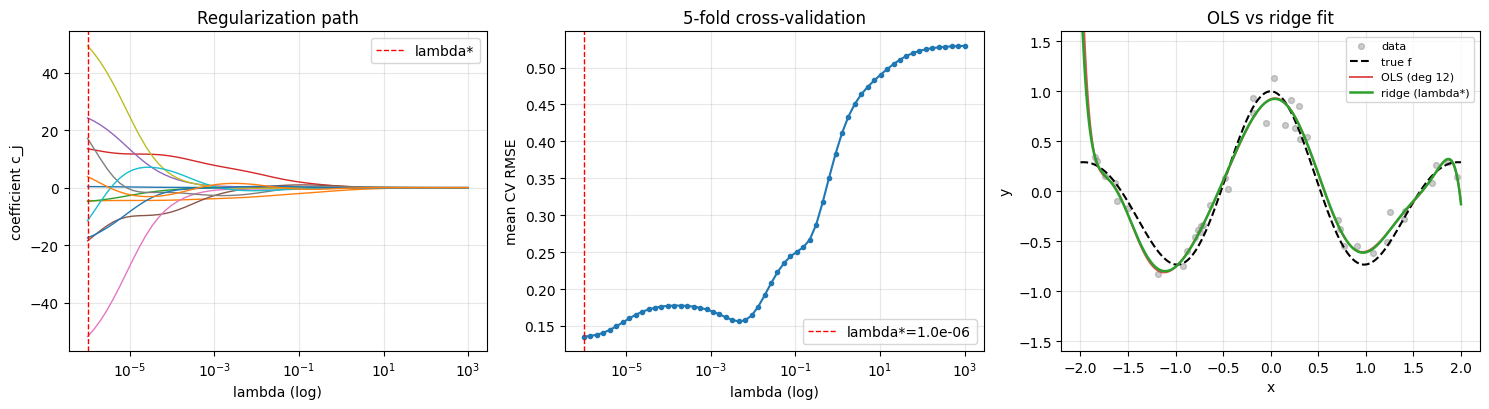

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) 정규화 경로
for j in range(1, deg+1):
    ax[0].plot(lams, path[:, j], lw=1)
ax[0].axvline(lam_star, color='r', ls='--', lw=1, label="lambda*")
ax[0].set_xscale('log'); ax[0].set_xlabel("lambda (log)")
ax[0].set_ylabel("coefficient c_j"); ax[0].set_title("Regularization path")
ax[0].legend(); ax[0].grid(alpha=0.3)

# (b) CV 곡선
ax[1].plot(lams, cv, 'o-', ms=3)
ax[1].axvline(lam_star, color='r', ls='--', lw=1, label=f"lambda*={lam_star:.1e}")
ax[1].set_xscale('log'); ax[1].set_xlabel("lambda (log)")
ax[1].set_ylabel("mean CV RMSE"); ax[1].set_title(f"{k}-fold cross-validation")
ax[1].legend(); ax[1].grid(alpha=0.3)

# (c) OLS vs ridge 적합
xx = np.linspace(-2, 2, 400)
Vx = ((np.vander(xx, deg+1, increasing=True) - mu)/sd); Vx[:,0]=1.0
ax[2].scatter(x, y, s=18, alpha=0.4, color='gray', label="data")
ax[2].plot(xx, f_true(xx), 'k--', lw=1.5, label="true f")
ax[2].plot(xx, Vx@c_ols,   'tab:red',  lw=1.4, alpha=0.8, label="OLS (deg 12)")
ax[2].plot(xx, Vx@c_ridge, 'tab:green',lw=1.8, label="ridge (lambda*)")
ax[2].set_ylim(-1.6, 1.6); ax[2].set_xlabel("x"); ax[2].set_ylabel("y")
ax[2].set_title("OLS vs ridge fit"); ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **정규화 경로**에서 $\lambda$ 가 커질수록 모든 계수가 0으로 수축한다. 작은 $\lambda$ 에서는 고차 계수가
   크게 진동(악조건의 증상)하지만, $\lambda$ 를 키우면 안정된다 — $\|\mathbf c\|_2$ 가 OLS 대비 수십~수백 배 줄어든다.
2. **CV 곡선은 U자형**이다. 너무 작은 $\lambda$ 는 과대적합(분산↑), 너무 큰 $\lambda$ 는 과소적합(편향↑).
   그 사이 $\lambda^\star$ 에서 검증오차가 최소가 된다 — 연속 파라미터로 복잡도를 조절하는 셈.
3. **OLS(차수 12)는 데이터 끝에서 심하게 요동**치지만, **CV로 고른 릿지 적합은 참 함수 $f$ 를 매끄럽게 추종**한다.
   $V^\top V$ 에 $\lambda I$ 를 더해 조건수를 낮춘 덕분에 수치적으로도 안정적이다.

> **결론**: 릿지 정규화는 악조건 설계행렬을 안정화하고($V^\top V+\lambda I$), $k$-겹 교차검증이 편향-분산을 균형 잡는 $\lambda^\star$ 를 데이터로부터 자동 선택한다.

**단원 마무리**: Problem 1(불확실성 정량화)–2(모델 선택)–3(정규화+CV)로 이어지는 흐름은
"수치해법을 *실데이터*에 적용할 때 반드시 따라붙는" 통계적 판단 — 신뢰구간, 복잡도 선택, 정규화 —
을 한 데 묶은 응용 사례연구다.